<a href="https://colab.research.google.com/github/selimkiotcs-prog/Urban-Analysis-SpatialDS-Project/blob/main/urban_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import geopandas as gpd
import rasterio
import rasterio.mask
from rasterio.plot import show
from rasterstats import zonal_stats
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import Point
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import seaborn as sns
#import contextily as ctx
import folium
from libpysal.weights import Queen
from esda.moran import Moran

In [ ]:
#mount google drive
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Upload datasets
# Landsat Bands
b4_path = "/content/drive/MyDrive/LC09_L2SP_168054_20260316_20260317_02_T1_SR_B4.TIF"
b5_path = "/content/drive/MyDrive/LC09_L2SP_168054_20260316_20260317_02_T1_SR_B5.TIF"
b6_path = "/content/drive/MyDrive/LC09_L2SP_168054_20260316_20260317_02_T1_SR_B6.TIF"

# Administrative Boundary shapefile
boundary_path = "/content/drive/MyDrive/gadm41_ETH_shp/gadm41_ETH_1.shp"

# Road Network shapefile
roads_path = "/content/drive/MyDrive/roaddata/gis_osm_roads_free_1.shp"

5. Load Vector Data

In [ ]:
#Administrative Boundary
boundary = gpd.read_file(boundary_path)
print(boundary.head())

     GID_1 GID_0   COUNTRY            NAME_1  \
0  ETH.1_1   ETH  Ethiopia       Addis Abeba   
1  ETH.2_1   ETH  Ethiopia              Afar   
2  ETH.3_1   ETH  Ethiopia            Amhara   
3  ETH.4_1   ETH  Ethiopia  Benshangul-Gumaz   
4  ETH.5_1   ETH  Ethiopia         Dire Dawa   

                          VARNAME_1 NL_NAME_1     TYPE_1 ENGTYPE_1 CC_1  \
0  Āddīs Ābaba|Addis Ababa|Adis-Abe        NA  Astedader      City   14   
1                                NA        NA      Kilil     State   02   
2                             Amara        NA      Kilil     State   03   
3                  Beneshangul Gumu        NA      Kilil     State   06   
4                                NA        NA  Astedader      City   15   

  HASC_1  ISO_1                                           geometry  
0  ET.AA     NA  POLYGON ((38.87945 8.91831, 38.87718 8.91253, ...  
1  ET.AF  ET-AF  POLYGON ((40.15225 8.93196, 40.14091 8.91891, ...  
2  ET.AM     NA  POLYGON ((39.74116 9.02302, 39.74616

In [ ]:
#Road Network
roads = gpd.read_file(roads_path)
print(roads.head())

    osm_id  code       fclass                      name   ref oneway  \
0  4677317  5122  residential                      None  None      B   
1  4677323  5122  residential                      None  None      B   
2  4677325  5122  residential                      None  None      B   
3  4677326  5122  residential                      None  None      B   
4  4677359  5113      primary  Equatorial Guinea Street  None      F   

   maxspeed  layer bridge tunnel  \
0         0      0      F      F   
1         0      0      F      F   
2         0      0      F      F   
3         0      0      F      F   
4         0      0      F      F   

                                            geometry  
0  LINESTRING (38.79066 9.01506, 38.79124 9.01521...  
1  LINESTRING (38.7916 9.01134, 38.7917 9.01075, ...  
2  LINESTRING (38.79085 9.01426, 38.79143 9.01439...  
3  LINESTRING (38.79342 9.01705, 38.79353 9.01656...  
4  LINESTRING (38.79534 9.01767, 38.79556 9.01774...  


6. Load Raster Data

In [ ]:
b4 = rasterio.open(b4_path)
b5 = rasterio.open(b5_path)
b6 = rasterio.open(b6_path)

print(b4.meta)

{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': 0.0, 'width': 7581, 'height': 7731, 'count': 1, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 37N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",39],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32637"]]'), 'transform': Affine(30.0, 0.0, 413385.0,
       0.0, -30.0, 1074615.0)}


1. Data Types Used
Vector Data
Administrative boundaries → Polygon
Road network → Line
Raster Data
Landsat Bands (B4, B5, B6)
Band Information
B4 = Red
B5 = Near Infrared (NIR)
B6 = Short Wave Infrared (SWIR)

2. data preprocessing

In [ ]:
#Coordinate System Transformation- ensures all datasets use the same CRS
print(boundary.crs)
print(roads.crs)
print(b4.crs)

EPSG:4326
EPSG:4326
EPSG:32637


In [ ]:
#Reproject Vector Data

boundary = boundary.to_crs(b4.crs)
roads = roads.to_crs(b4.crs)

In [ ]:
#Select Addis Ababa Boundary
addis = boundary[boundary['NAME_1'] == 'Addis Abeba']

print(addis)

     GID_1 GID_0   COUNTRY       NAME_1                         VARNAME_1  \
0  ETH.1_1   ETH  Ethiopia  Addis Abeba  Āddīs Ābaba|Addis Ababa|Adis-Abe   

  NL_NAME_1     TYPE_1 ENGTYPE_1 CC_1 HASC_1 ISO_1  \
0        NA  Astedader      City   14  ET.AA    NA   

                                            geometry  
0  POLYGON ((486746.674 985823.38, 486497.347 985...  


In [ ]:
print(boundary.columns)
print(boundary.head())

Index(['GID_1', 'GID_0', 'COUNTRY', 'NAME_1', 'VARNAME_1', 'NL_NAME_1',
       'TYPE_1', 'ENGTYPE_1', 'CC_1', 'HASC_1', 'ISO_1', 'geometry'],
      dtype='object')
     GID_1 GID_0   COUNTRY            NAME_1  \
0  ETH.1_1   ETH  Ethiopia       Addis Abeba   
1  ETH.2_1   ETH  Ethiopia              Afar   
2  ETH.3_1   ETH  Ethiopia            Amhara   
3  ETH.4_1   ETH  Ethiopia  Benshangul-Gumaz   
4  ETH.5_1   ETH  Ethiopia         Dire Dawa   

                          VARNAME_1 NL_NAME_1     TYPE_1 ENGTYPE_1 CC_1  \
0  Āddīs Ābaba|Addis Ababa|Adis-Abe        NA  Astedader      City   14   
1                                NA        NA      Kilil     State   02   
2                             Amara        NA      Kilil     State   03   
3                  Beneshangul Gumu        NA      Kilil     State   06   
4                                NA        NA  Astedader      City   15   

  HASC_1  ISO_1                                           geometry  
0  ET.AA     NA  POLYGON ((

In [ ]:
print(boundary['NAME_1'].unique())

['Addis Abeba' 'Afar' 'Amhara' 'Benshangul-Gumaz' 'Dire Dawa'
 'Gambela Peoples' 'Harari People' 'Oromia' 'Somali'
 'Southern Nations, Nationalities' 'Tigray']


In [ ]:
addis = boundary[boundary['NAME_1'] == 'Addis Abeba']
print(addis)

     GID_1 GID_0   COUNTRY       NAME_1                         VARNAME_1  \
0  ETH.1_1   ETH  Ethiopia  Addis Abeba  Āddīs Ābaba|Addis Ababa|Adis-Abe   

  NL_NAME_1     TYPE_1 ENGTYPE_1 CC_1 HASC_1 ISO_1  \
0        NA  Astedader      City   14  ET.AA    NA   

                                            geometry  
0  POLYGON ((486746.674 985823.38, 486497.347 985...  


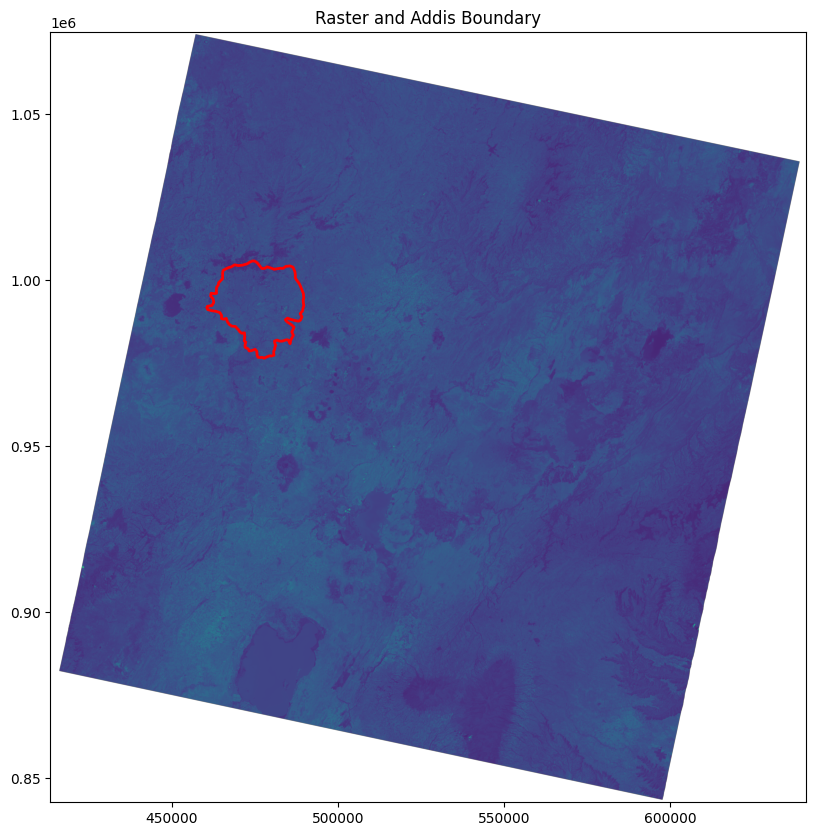

In [ ]:
from rasterio.plot import show

fig, ax = plt.subplots(figsize=(10,10))

show(b4, ax=ax)

addis.boundary.plot(ax=ax,
                    edgecolor='red',
                    linewidth=2)

plt.title("Raster and Addis Boundary")

plt.show()

In [ ]:
#Clip Raster Using Addis Ababa Boundary
from rasterio.mask import mask

geoms = addis.geometry.values

red_clip, red_transform = mask(b4, geoms, crop=True)
nir_clip, nir_transform = mask(b5, geoms, crop=True)
swir_clip, swir_transform = mask(b6, geoms, crop=True)

print(red_clip.shape)
print(nir_clip.shape)
print(swir_clip.shape)

(1, 977, 979)
(1, 977, 979)
(1, 977, 979)


In [ ]:
print(np.unique(red_clip[0])[:10])

print(np.unique(nir_clip[0])[:10])

print(np.unique(swir_clip[0])[:10])

[   0 6660 7821 7896 7937 7991 8041 8047 8051 8060]
[   0 7708 8018 8159 8162 8265 8301 8402 8478 8489]
[   0 8034 8071 8117 8217 8262 8274 8296 8302 8341]


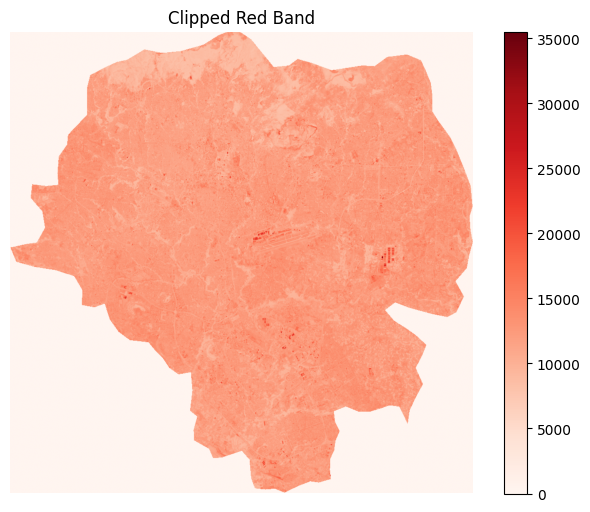

In [ ]:
plt.figure(figsize=(8,6))

plt.imshow(red_clip[0], cmap='Reds')

plt.colorbar()

plt.title('Clipped Red Band')

plt.axis('off')

plt.show()

In [ ]:
print("Boundary CRS:", addis.crs)

print("Raster CRS:", b4.crs)

Boundary CRS: PROJCS["WGS 84 / UTM zone 37N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",39],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32637"]]
Raster CRS: EPSG:32637


In [ ]:
#Data Cleaning- Remove NoData Values
red = red_clip[0].astype(float)
nir = nir_clip[0].astype(float)
swir = swir_clip[0].astype(float)

red[red == b4.nodata] = np.nan
nir[nir == b5.nodata] = np.nan
swir[swir == b6.nodata] = np.nan

In [ ]:
#Handling Missing Values
imputer = SimpleImputer(strategy='mean')

red_filled = imputer.fit_transform(red)
nir_filled = imputer.fit_transform(nir)
swir_filled = imputer.fit_transform(swir)

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [0]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [0]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [0]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


In [ ]:
#Data Integration- Combine raster layers into one dataset.
stacked = np.dstack((red_filled, nir_filled, swir_filled))

print(stacked.shape)

(977, 978, 3)


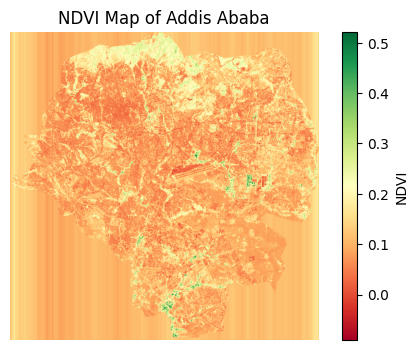

[[0.12056979 0.10506883 0.1194184  ... 0.14652867 0.12455736 0.15867873]
 [0.12056979 0.10506883 0.1194184  ... 0.14652867 0.12455736 0.15867873]
 [0.12056979 0.10506883 0.1194184  ... 0.14652867 0.12455736 0.15867873]
 ...
 [0.12056979 0.10506883 0.1194184  ... 0.14652867 0.12455736 0.15867873]
 [0.12056979 0.10506883 0.1194184  ... 0.14652867 0.12455736 0.15867873]
 [0.12056979 0.10506883 0.1194184  ... 0.14652867 0.12455736 0.15867873]]


In [ ]:
#NDVI Calculation- Normalized Difference Vegetation Index.
ndvi = (nir_filled - red_filled) / (nir_filled + red_filled)

plt.figure(figsize=(6,4))
plt.imshow(ndvi, cmap='RdYlGn')
plt.colorbar(label='NDVI')
plt.title('NDVI Map of Addis Ababa')
plt.axis('off')
plt.show()
print(ndvi)

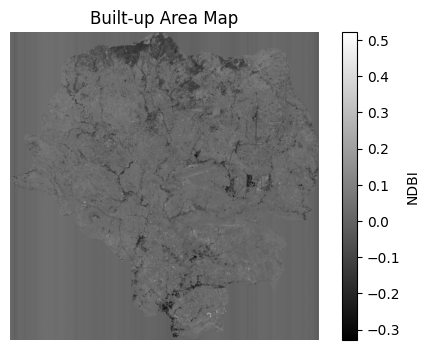

[[ 0.01497813  0.02731061  0.03506382 ... -0.01663128  0.01050932
   0.02206437]
 [ 0.01497813  0.02731061  0.03506382 ... -0.01663128  0.01050932
   0.02206437]
 [ 0.01497813  0.02731061  0.03506382 ... -0.01663128  0.01050932
   0.02206437]
 ...
 [ 0.01497813  0.02731061  0.03506382 ... -0.01663128  0.01050932
   0.02206437]
 [ 0.01497813  0.02731061  0.03506382 ... -0.01663128  0.01050932
   0.02206437]
 [ 0.01497813  0.02731061  0.03506382 ... -0.01663128  0.01050932
   0.02206437]]


In [ ]:
#NDBI Calculation- Normalized Difference Built-up Index.
ndbi = (swir_filled - nir_filled) / (swir_filled + nir_filled)

plt.figure(figsize=(6,4))
plt.imshow(ndbi, cmap='gray')
plt.colorbar(label='NDBI')
plt.title('Built-up Area Map')
plt.axis('off')
plt.show()
print(ndbi)

In [ ]:
#Spatial Querying- Find roads inside Addis Ababa.
roads_addis = gpd.overlay(roads, addis, how='intersection')

print(roads_addis.head(10))

    osm_id  code       fclass                      name   ref oneway  \
0  4677317  5122  residential                      None  None      B   
1  4677323  5122  residential                      None  None      B   
2  4677325  5122  residential                      None  None      B   
3  4677326  5122  residential                      None  None      B   
4  4677359  5113      primary  Equatorial Guinea Street  None      F   
5  4677416  5113      primary   Ras Abebe Aregay Street  None      F   
6  4677442  5113      primary         Mozambique Street  None      F   
7  4677450  5113      primary                      None  None      F   
8  4677458  5113      primary               Chad Street  None      F   
9  4677463  5113      primary             Uganda Street  None      F   

   maxspeed  layer bridge tunnel  ...   COUNTRY       NAME_1  \
0         0      0      F      F  ...  Ethiopia  Addis Abeba   
1         0      0      F      F  ...  Ethiopia  Addis Abeba   
2         0    

In [ ]:
#Buffer Analysis-Create 500m road buffer.
roads_buffer = roads_addis.buffer(500)

buffer_gdf = gpd.GeoDataFrame(geometry=roads_buffer, crs=roads_addis.crs)

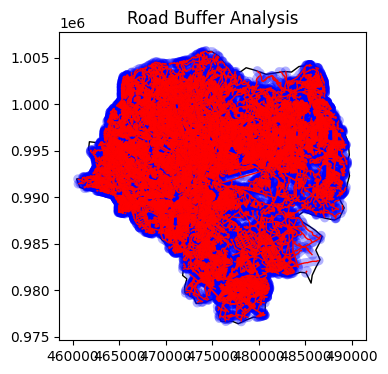

In [ ]:
#buffer plot
fig, ax = plt.subplots(figsize=(6,4))

addis.plot(ax=ax, color='white', edgecolor='black')
roads_addis.plot(ax=ax, color='red', linewidth=1)
buffer_gdf.plot(ax=ax, color='blue', alpha=0.3)

plt.title('Road Buffer Analysis')
plt.show()

In [ ]:
print(np.nanmin(ndbi))
print(np.nanmax(ndbi))

-0.32895448156557466
0.5219407561819308


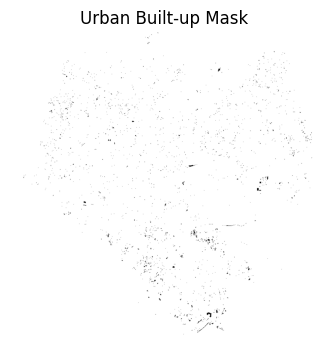

In [ ]:
#Overlay Analysis- Overlay built-up areas and road buffers
# Remove NaN values
ndbi = np.nan_to_num(ndbi)

urban_mask = (ndbi > 0.1).astype(int)

plt.figure(figsize=(6,4))
plt.imshow(urban_mask, cmap='binary')
plt.title('Urban Built-up Mask')
plt.axis('off')
plt.show()

In [ ]:
#Raster to DataFrame Conversion- Prepare raster data for machine learning.
rows, cols = ndvi.shape

X = pd.DataFrame({
    'Red': red_filled.flatten(),
    'NIR': nir_filled.flatten(),
    'SWIR': swir_filled.flatten(),
    'NDVI': ndvi.flatten(),
    'NDBI': ndbi.flatten()
})


print(X.head())

            Red           NIR          SWIR      NDVI      NDBI
0  12903.000000  16441.000000  16941.000000  0.120570  0.014978
1  13573.600000  16760.800000  17702.000000  0.105069  0.027311
2  13211.428571  16794.714286  18015.285714  0.119418  0.035064
3  12721.111111  16313.444444  17062.555556  0.123726  0.022445
4  12427.166667  16475.750000  17207.666667  0.140075  0.021729


In [ ]:

print(red_filled.shape)
print(nir_filled.shape)
print(swir_filled.shape)

(977, 978)
(977, 978)
(977, 978)


In [ ]:
print(np.nanmin(red_filled), np.nanmax(red_filled))
print(np.nanmin(nir_filled), np.nanmax(nir_filled))
print(np.nanmin(swir_filled), np.nanmax(swir_filled))

6660.0 35522.0
7708.0 36125.0
8034.0 55891.0


In [ ]:
#Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# kmean
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

X['Cluster'] = clusters

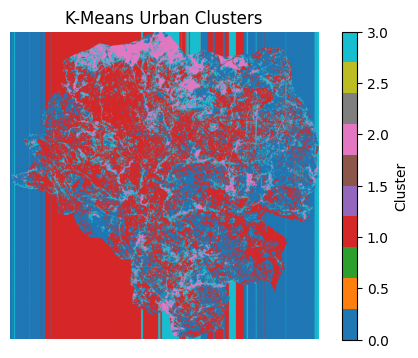

In [ ]:
#visualize clusters
cluster_map = np.full(ndvi.flatten().shape, np.nan)
cluster_map[:len(clusters)] = clusters
cluster_map = cluster_map.reshape(ndvi.shape)

plt.figure(figsize=(6,4))
plt.imshow(cluster_map, cmap='tab10')
plt.title('K-Means Urban Clusters')
plt.colorbar(label='Cluster')
plt.axis('off')
plt.show()

In [ ]:
# dbscan- to custer urban hotspot
sample_data = X_scaled[:10000]

model = DBSCAN(eps=0.5, min_samples=10)
dbscan_clusters = model.fit_predict(sample_data)

print(np.unique(dbscan_clusters))

[-1  0  1  2  3  4]


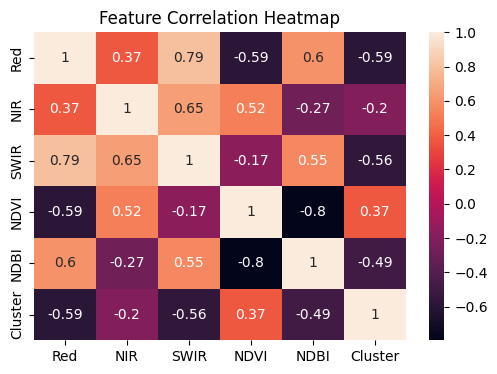

In [ ]:
#haeatmap  visualization
plt.figure(figsize=(6,4))
sns.heatmap(X.corr(), annot=True)
plt.title('Feature Correlation Heatmap')
plt.show()

In [ ]:
#choroplrth map
stats = zonal_stats(addis, ndvi, affine=red_transform, stats=['mean'])

addis['Mean_NDVI'] = [s['mean'] for s in stats]

/usr/local/lib/python3.12/dist-packages/rasterstats/io.py:335: NodataWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


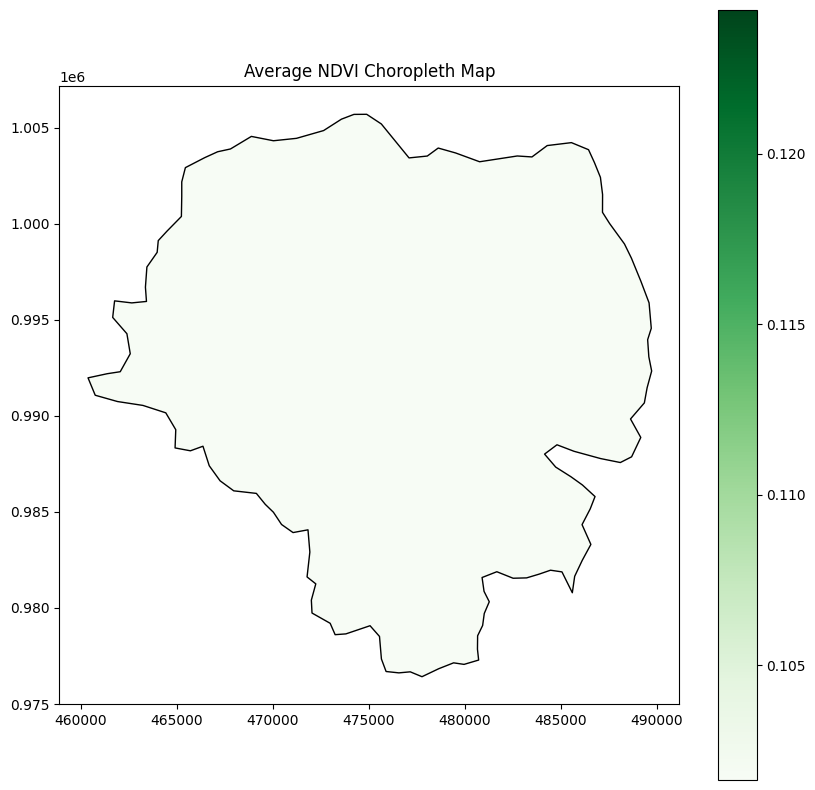

In [ ]:
#plot choroplets
fig, ax = plt.subplots(figsize=(10,10))

addis.plot(column='Mean_NDVI',
           cmap='Greens',
           legend=True,
           edgecolor='black',
           ax=ax)

plt.title('Average NDVI Choropleth Map')
plt.show()

In [ ]:
#interactive map
m = folium.Map(location=[9.03, 38.74], zoom_start=10)

folium.GeoJson(addis).add_to(m)

m

In [ ]:
#spatial autocorrolation
w = Queen.from_dataframe(addis)

moran = Moran(addis['Mean_NDVI'], w)

print('Moran I:', moran.I)
print('p-value:', moran.p_sim)

In [ ]:
# ML for spatial prediction
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
X['Urban'] = (X['NDBI'] > 0).astype(int)
features = X[['Red', 'NIR', 'SWIR', 'NDVI']]
labels = X['Urban']

X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=0.3,
    random_state=42
)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     55885
           1       1.00      1.00      1.00    230767

    accuracy                           1.00    286652
   macro avg       1.00      1.00      1.00    286652
weighted avg       1.00      1.00      1.00    286652



In [ ]:
# feature importance
importance = pd.DataFrame({
    'Feature': features.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

print(importance)

  Feature  Importance
3    NDVI    0.337756
2    SWIR    0.310084
0     Red    0.177701
1     NIR    0.174460


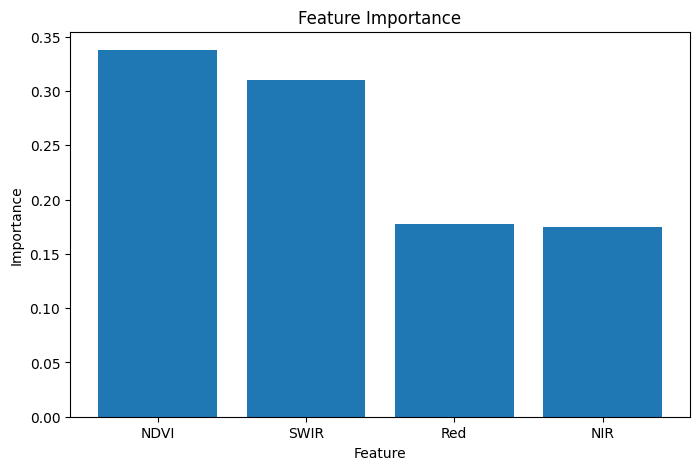

In [ ]:
#plot importance
plt.figure(figsize=(8,5))
plt.bar(importance['Feature'], importance['Importance'])
plt.title('Feature Importance')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.show()

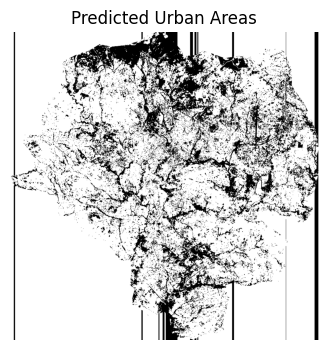

In [ ]:
#final urban classification map
prediction = rf.predict(features)

urban_prediction = prediction.reshape(ndvi.shape)

plt.figure(figsize=(6,4))
plt.imshow(urban_prediction, cmap='gray')
plt.title('Predicted Urban Areas')
plt.axis('off')
plt.show()